In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn scikit-fuzzy


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import skfuzzy as fuzz

In [5]:
df = pd.read_csv("COVID19MEXICO.csv", low_memory=False)

df.head()

,FECHA_ACTUALIZACION,ID_REGISTRO,ORIGEN,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_NAC,ENTIDAD_RES,MUNICIPIO_RES,TIPO_PACIENTE,...,RESULTADO_PCR,RESULTADO_PCR_COINFECCION,TOMA_MUESTRA_ANTIGENO,RESULTADO_ANTIGENO,CLASIFICACION_FINAL_COVID,CLASIFICACION_FINAL_FLU,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,2026-01-06,167f1a,1,12,1,2,1,1,3,1,...,997,997,2,97,6,6,99,México,97,97
1,2026-01-06,g6ee40d,1,6,9,2,15,9,10,1,...,997,997,2,97,6,6,99,México,97,97
2,2026-01-06,g64373f,1,15,32,1,32,32,56,1,...,34,998,2,97,3,7,99,México,97,97
3,2026-01-06,gc8193f,1,15,32,1,32,32,57,2,...,5,5,2,97,7,7,99,México,97,2
4,2026-01-06,gc32852,1,4,21,1,21,21,156,1,...,5,5,2,97,7,7,99,México,97,97


In [6]:
df = df[df["CLASIFICACION_FINAL_COVID"].isin([1, 2, 3])]

df.shape

(7248, 42)

In [7]:
df["RESULTADO"] = df["FECHA_DEF"].apply(
    lambda x: 0 if x == "9999-99-99" else 1
)

In [8]:
vars_selected = [
    "EDAD",
    "SEXO",
    "NEUMONIA",
    "DIABETES",
    "HIPERTENSION",
    "OBESIDAD",
    "RENAL_CRONICA",
    "UCI",
    "INTUBADO",
    "RESULTADO"
]

df = df[vars_selected]

df.head()


,EDAD,SEXO,NEUMONIA,DIABETES,HIPERTENSION,OBESIDAD,RENAL_CRONICA,UCI,INTUBADO,RESULTADO
2,50,1,2,1,2,2,2,97,97,0
42,13,1,2,2,2,2,2,2,2,0
47,45,1,1,2,2,2,2,2,2,0
75,45,2,2,2,2,2,2,97,97,0
86,28,1,2,2,2,2,2,97,97,0


In [9]:
df.replace([97, 98, 99, 997], np.nan, inplace=True)

df.dropna(inplace=True)

df.shape


(3211, 10)

In [10]:
binary_cols = [
    "NEUMONIA",
    "DIABETES",
    "HIPERTENSION",
    "OBESIDAD",
    "RENAL_CRONICA",
    "UCI",
    "INTUBADO"
]

for col in binary_cols:
    df[col] = df[col].map({1: 1, 2: 0})

df["SEXO"] = df["SEXO"].map({1: 1, 2: 0})

df.head()


,EDAD,SEXO,NEUMONIA,DIABETES,HIPERTENSION,OBESIDAD,RENAL_CRONICA,UCI,INTUBADO,RESULTADO
42,13.0,1,0,0,0,0,0,0,0,0
47,45.0,1,1,0,0,0,0,0,0,0
93,20.0,1,1,0,0,0,0,0,0,0
98,70.0,1,1,1,0,0,0,0,0,0
128,2.0,0,1,0,0,0,0,0,0,0


In [11]:
X = df.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

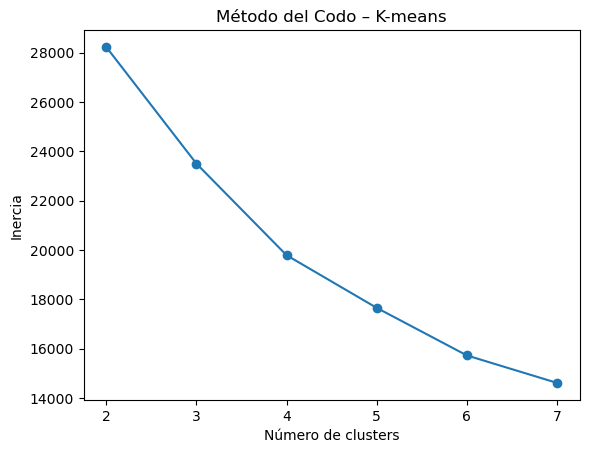

In [12]:
inertia = []
K = range(2, 8)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo – K-means")
plt.show()


In [13]:
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k} → silhouette={score:.3f}")


k=2 → silhouette=0.352
k=3 → silhouette=0.300
k=4 → silhouette=0.310
k=5 → silhouette=0.321


In [14]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

df["cluster_kmeans"].value_counts()


cluster_kmeans
0    2018
2     936
1     257
Name: count, dtype: int64

In [15]:
cluster_summary = df.groupby("cluster_kmeans").mean()
cluster_summary

,EDAD,SEXO,NEUMONIA,DIABETES,HIPERTENSION,OBESIDAD,RENAL_CRONICA,UCI,INTUBADO,RESULTADO
cluster_kmeans,,,,,,,,,,
0,27.824083,0.507433,0.403370,0.013380,0.007433,0.029237,0.0,0.023786,0.021804,0.026264
1,58.229572,0.556420,0.482490,0.610895,0.715953,0.206226,1.0,0.019455,0.050584,0.167315
2,69.673077,0.527778,0.584402,0.579060,0.696581,0.162393,0.0,0.053419,0.105769,0.290598


In [16]:
X_fuzzy = X_scaled.T

cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    X_fuzzy,
    c=3,
    m=2,
    error=0.005,
    maxiter=1000,
    init=None
)

df["cluster_fuzzy"] = np.argmax(u, axis=0)

df["cluster_fuzzy"].value_counts()


cluster_fuzzy
0    1264
1    1044
2     903
Name: count, dtype: int64

In [17]:
pd.crosstab(df["cluster_kmeans"], df["cluster_fuzzy"])

cluster_fuzzy,0,1,2
cluster_kmeans,,,
0,1226,0,792
1,13,217,27
2,25,827,84


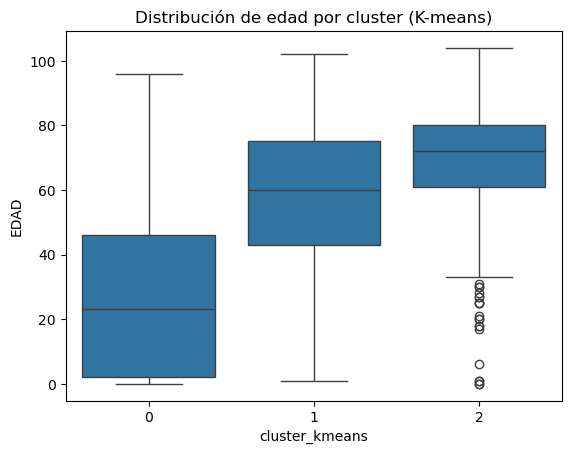

In [18]:
sns.boxplot(x="cluster_kmeans", y="EDAD", data=df)
plt.title("Distribución de edad por cluster (K-means)")
plt.show()


In [19]:
df.to_csv("data_covid_clusters.csv", index=False)